Saving Sample - Superstore.csv to Sample - Superstore (1).csv
Dataset loaded!
Shape: (9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ... 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

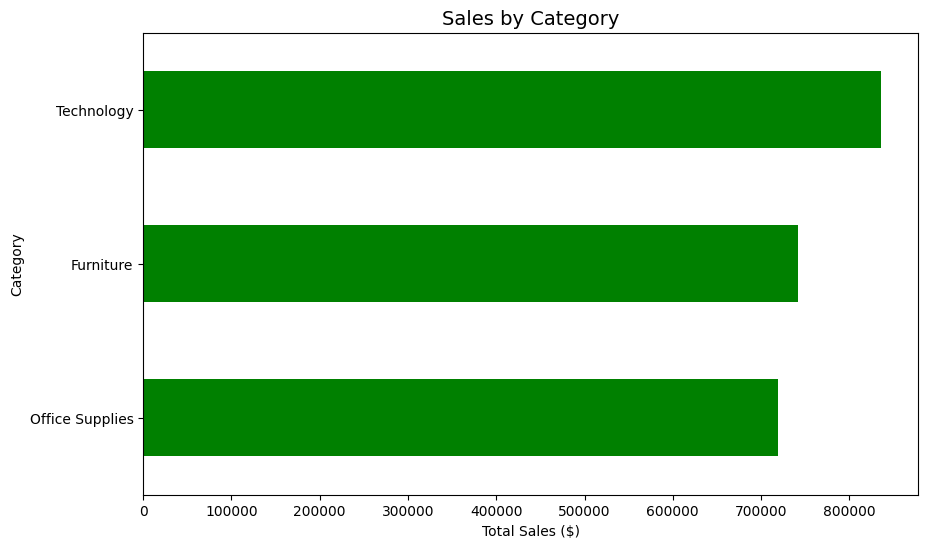

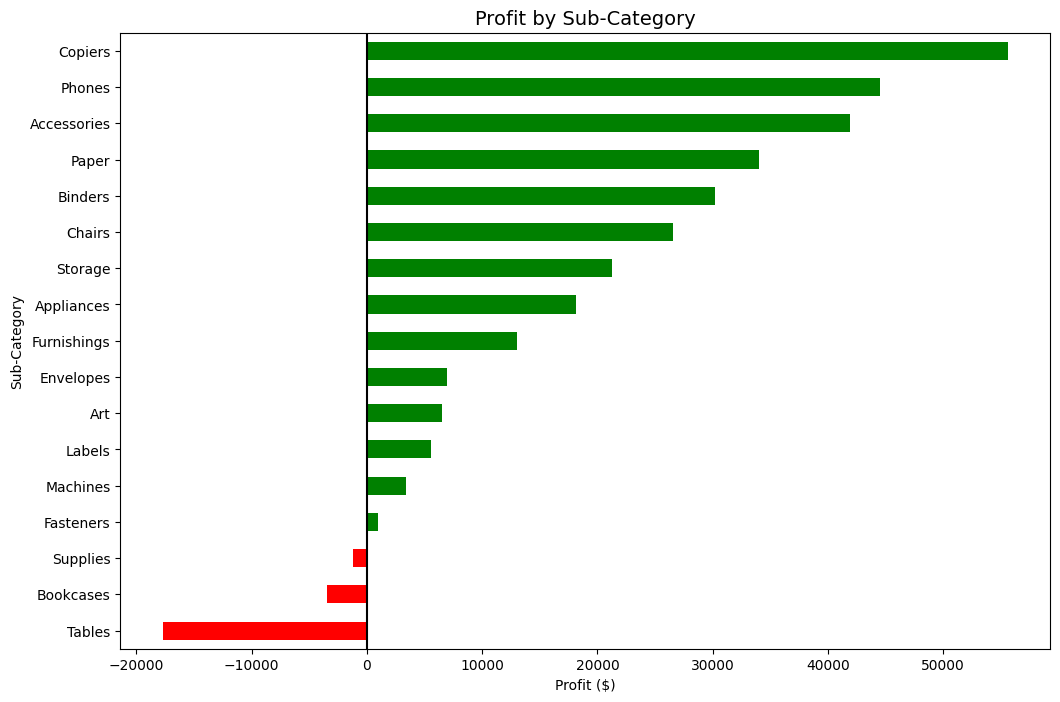

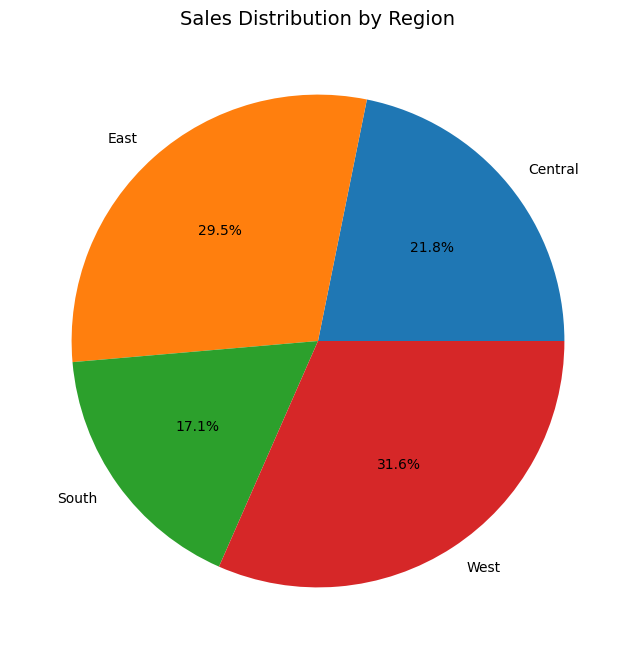

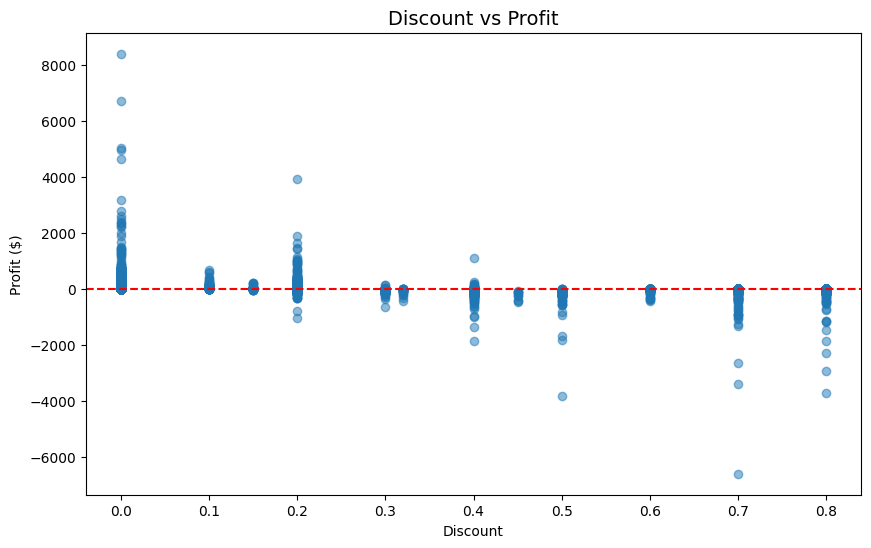


PROJECT SUMMARY
Total rows after cleaning: 9994
Total sales: $2,297,200.86
Total profit: $286,397.02
Top category: Technology
Top region: West


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), encoding='latin1')

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicates: {df.duplicated().sum()}")

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create shipping days column
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Remove duplicates if any
df = df.drop_duplicates()

# Save cleaned data
df.to_csv('superstore_cleaned.csv', index=False)
files.download('superstore_cleaned.csv')

# Visualization 1: Sales by Category
plt.figure(figsize=(10,6))
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh', color='green')
plt.title('Sales by Category', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.show()

# Visualization 2: Profit by Sub-Category
plt.figure(figsize=(12,8))
profit_data = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'green' for x in profit_data]
profit_data.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category', fontsize=14)
plt.xlabel('Profit ($)')
plt.axvline(x=0, color='black')
plt.show()

# Visualization 3: Sales by Region
plt.figure(figsize=(8,8))
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Distribution by Region', fontsize=14)
plt.ylabel('')
plt.show()

# Visualization 4: Discount vs Profit
plt.figure(figsize=(10,6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Discount vs Profit', fontsize=14)
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.show()

# Summary
print("\n" + "="*50)
print("PROJECT SUMMARY")
print("="*50)
print(f"Total rows after cleaning: {df.shape[0]}")
print(f"Total sales: ${df['Sales'].sum():,.2f}")
print(f"Total profit: ${df['Profit'].sum():,.2f}")
print(f"Top category: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Top region: {df.groupby('Region')['Sales'].sum().idxmax()}")